In [80]:
from __future__ import annotations
from dataclasses import dataclass, field
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from pymrm import (
    NumJac,
    construct_coefficient_matrix,
    construct_convflux_upwind,
    construct_div,
    construct_grad,
    newton,
    non_uniform_grid,
)


In [81]:

@dataclass
class ModelConfig:
    length: float = 10 # length
    R_ret: float = 15e-3 # radius of retentate
    R_perm: float = R_ret + 5e-4 # radius of permeate
    R_out: float = 17e-3 # outer radius

    P_vector: np.ndarray = field(default_factory=lambda: np.array([0.000, 0.000, 0.000, 0.002, 0.000])) # membrane permeability
    v_ret: float = 0.005 # velocity of retentate
    v_perm: float = 0.001 # velocity of permeate
    d_ax: float = 2.0e-5 # dispersion in the axial direction
    
    n_z: int = 100 # number of grid points in the axial direction
    n_r_perm: int = 30 # number of grid points in the radial direction of permeate
    n_r_ret: int = 30 # number of grid points in the radial direction of retentate
    n_c: int = 5 # number of components

# Catalyst & Thermodynamic Parameters
    particle_radius: float = 1.0e-3  # Catalyst particle radius [m]
    particle_diffusivity: np.ndarray = field(
        default_factory=lambda: np.array([2.0e-6, 1.5e-6, 1.5e-6, 1.5e-6, 1.5e-6])
    )  # Diffusivity per component [m²/s]
    eps_s: float = 0.4  # Solid holdup (catalyst bed voidage component) [-]
    rho_cat: float = 1500 # Catalyst density [kg/m³]
    mu: float = 1.0e-3  # Gas viscosity [Pa·s]
    dp: float = 2.0e-3  # Particle diameter [m]
    T: float = 400.0  # Operating temperature [K]
    R: float = 8.314  # Ideal gas constant [J/(mol·K)]
    D_eff: float = 1.0e-5  # Effective film diffusivity [m²/s]
    p: float = 30e5  # Operational Pressure [Pa]
    p_0: float = 200e5  # Reference Pressure for volume change [Pa]

    # Kinetic Parameters: Reaction 1 (CO2 + 3H2 <-> MeOH + H2O) (Ghosh et al.)
    T_ref: float = 573.15  # Reference temperature [K] (300 °C)
    k1_pre: float = 6.9e-4  # Forward rate constant at T_ref [mol/(s·bar²·kg_cat)]
    k1_eq: float = 2.5e-4  # Equilibrium constant at T_ref [bar⁻²]
    Ea_1: float = 35.7e3  # Activation energy [J/mol]
    K_CO2_ref: float = 0.79  # CO2 adsorption constant at T_ref [bar⁻¹]
    dH_CO2: float = -25.9e3  # Enthalpy of adsorption for CO2 [J/mol]
    K_H2_ref: float = 0.76  # H2 adsorption constant at T_ref [bar⁻¹]
    dH_H2: float = -12.5e3  # Enthalpy of adsorption for H2 [J/mol]

    # Kinetic Parameters: Reaction 2 (CO2 + 2MeOH <-> DMC + H2O) (ibrahim et al.)  
    k2_pre: float = 1.15e-3  # Pre-exponential factor [s⁻¹]
    Ea_DMC: float = 106e3  # Activation energy [J/mol]
    dV: float = -3.775e-4  # Reaction volume change [m³/mol]
    k2_eq: float = 44.5e-14  # Equilibrium constant at 400 K [-]

    inlet_concentration: np.ndarray = field(default_factory=lambda: np.array([4500, 13500, 0, 0, 0])) # inlet concentration of the components, CO2, H2, CH3OH, H2O, DMC

    tol: float = 1.0e-6  # tolerance for convergence
    maxfev: int = 30    # maximum number of function evaluations

    def k_eff_r1(self) -> float:
        return self.k1_pre * np.exp(
            (self.Ea_1 / self.R) * (1.0 / self.T_ref - 1.0 / self.T))
    
    def k_eff_r2(self, P_total_Pa: float | np.ndarray) -> float | np.ndarray:
        return self.k2_pre * np.exp(
            (-self.Ea_DMC - self.dV * (P_total_Pa - self.p_0)) / (self.R * self.T))
    
    def K_ads(self, K_ref: float, dH: float) -> float:
        return K_ref * np.exp((-dH / self.R) * (1.0 / self.T_ref - 1.0 / self.T))

    @property # external paricle surface area per unit bed volume
    def external_area(self):
        return 3.0 * self.eps_s / self.particle_radius
    
    @property # Membrane interfacial area per unit volume of retentate tube (2 π R_ret L / (π R_ret² L) = 2 / R_ret )
    def a_ret(self):
        return 2.0 / self.R_ret
    
    @property # membrane area per unit volume of the permeate (2 π R_ret L / (π (R_out² - R_perm²) L) = 2 R_ret / (R_out² - R_perm²))
    def a_perm(self):
        return 2.0 * self.R_ret / (self.R_out**2 - self.R_perm**2)
    
    @property
    def rho_bulk(self):
        return (1 - self.eps_s) * self.rho_cat  # kg_cat/m³_reactor

cfg = ModelConfig()

pd.Series(
    {
            "axial cells":               cfg.n_z,
            "particle radial cells":     cfg.n_r_ret,
            "reactor length [m]":        cfg.length,
            "v_ret [m/s]":               cfg.v_ret,
            "v_perm [m/s]":              cfg.v_perm,
            "particle radius [mm]":      1e3 * cfg.particle_radius,
            "solid holdup [-]":          cfg.eps_s,
            "external area [1/m]":       cfg.external_area,
            "retentate area [1/m]":      cfg.a_ret,
            "permeate area [1/m]":       cfg.a_perm,
        },
    name="settings",
)



axial cells               100.000000
particle radial cells      30.000000
reactor length [m]         10.000000
v_ret [m/s]                 0.005000
v_perm [m/s]                0.001000
particle radius [mm]        1.000000
solid holdup [-]            0.400000
external area [1/m]      1200.000000
retentate area [1/m]      133.333333
permeate area [1/m]       615.384615
Name: settings, dtype: float64

In [82]:
class TransportOperators:
    def __init__(self, cfg: ModelConfig) -> None:
        self.cfg = cfg
        # Shape descriptors (mirrors MembraneReactorModel)
        self.gas_shape        = (cfg.n_z, cfg.n_c)
        self.boundary_shape   = (cfg.n_z, 1, cfg.n_c)
        self.particle_shape   = (cfg.n_z, cfg.n_r_ret, cfg.n_c)

        self._build_grids()
        self._build_operators()

    def _build_grids(self) -> None:
        cfg = self.cfg
        # Axial grid
        self.z_f = np.linspace(0.0, cfg.length, cfg.n_z + 1)
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])

        # Retentate particle: non-uniform radial grid (refined near surface)
        self.r_f_ret = non_uniform_grid(
            0.0, cfg.particle_radius, cfg.n_r_ret + 1,
            0.15 * cfg.particle_radius, 0.75
        )
        self.r_c_ret = 0.5 * (self.r_f_ret[:-1] + self.r_f_ret[1:])

        # Permeate annulus: non-uniform radial grid (built for future use)
        self.r_f_perm = non_uniform_grid(
            cfg.R_ret, cfg.R_perm, cfg.n_r_perm + 1,
            0.15 * (cfg.R_perm - cfg.R_ret), 0.75
        )
        self.r_c_perm = 0.5 * (self.r_f_perm[:-1] + self.r_f_perm[1:])

        # Radial quadrature weights: w_j = Δ(r³_j) / r³_max  (spherical volume element)
        self.volume_weights = np.diff(self.r_f_ret**3) / self.r_f_ret[-1]**3


    def _build_operators(self) -> None:
        cfg = self.cfg
        # BCs: Danckwerts inlet (Dirichlet concentration), zero-gradient outlet
        bc_axial = (
            {"a": 0.0, "b": 1.0, "d": cfg.inlet_concentration},  # z=0: c = c_in
            {"a": 1.0, "b": 0.0, "d": 0.0},                      # z=L: dc/dz = 0
        )
        grad_mat, grad_bc = construct_grad(self.gas_shape, self.z_f, self.z_c, bc=bc_axial, axis=0)
        conv_mat, conv_bc = construct_convflux_upwind(self.gas_shape, self.z_f, self.z_c, bc=bc_axial, v=cfg.v_ret, axis=0)
        div_mat = construct_div(self.gas_shape, self.z_f, axis=0)
        d_ax_mat = construct_coefficient_matrix(cfg.d_ax, self.gas_shape, axis=0)
        self.gas_transport_mat   = div_mat @ (conv_mat - d_ax_mat @ grad_mat)
        self.gas_transport_const = div_mat @ (conv_bc  - d_ax_mat @ grad_bc)

        # BCs: symmetry at centre (zero flux), Dirichlet at outer surface (= boundary layer)
        bc_particle = (
            {"a": 1.0, "b": 0.0, "d": 0.0},   # r=0: zero flux (symmetry)
            {"a": 0.0, "b": 1.0, "d": 1.0},   # r=R_p: c = c_boundary (overridden by bc vector)
        )
        grad_p_mat, _, grad_p_bc = construct_grad(self.particle_shape, self.r_f_ret, self.r_c_ret, bc=bc_particle, axis=1, shapes_d=(None, self.boundary_shape), )
        div_p_mat = construct_div(self.particle_shape, self.r_f_ret, nu=2, axis=1)
        d_p = cfg.particle_diffusivity.reshape(1, 1, cfg.n_c)
        d_p_mat = construct_coefficient_matrix(d_p, self.particle_shape, axis=1)
        flux_p_mat = -d_p_mat @ grad_p_mat   
        flux_p_bc  = -d_p_mat @ grad_p_bc    
        self.particle_diffusion_mat  = div_p_mat @ flux_p_mat
        self.particle_boundary_mat   = div_p_mat @ flux_p_bc

        face_shape = (cfg.n_z, cfg.n_r_ret + 1, cfg.n_c)
        outer_face_rows = (
            face_shape[2] * face_shape[1] * np.arange(face_shape[0]).reshape((-1, 1))
            + face_shape[2] * cfg.n_r_ret
            + np.arange(face_shape[2]).reshape((1, -1))
        ).ravel()

        self.particle_apparent_mat    = (3.0 / cfg.particle_radius) * flux_p_mat[outer_face_rows, :]
        self.particle_apparent_bc_mat = (3.0 / cfg.particle_radius) * flux_p_bc[outer_face_rows, :]

        # BCs: zero concentration at permeate inlet (z=L), zero-gradient at z=0.
        bc_permeate = (
            {"a": 0.0, "b": 1.0, "d": 0.0},   # z=0: c_perm = 0 (or sweep gas)
            {"a": 1.0, "b": 0.0, "d": 0.0},   # z=L: dc/dz = 0
        )
        conv_mat_m, conv_bc_m = construct_convflux_upwind(
            self.gas_shape, self.z_f, self.z_c, bc=bc_permeate, v=cfg.v_perm, axis=0
        )
        div_mat_m = construct_div(self.gas_shape, self.z_f, axis=0)

        self.perm_transport_mat   = div_mat_m @ conv_mat_m
        self.perm_transport_const = div_mat_m @ conv_bc_m

In [83]:
STOICH = np.array(
    [
        [-1.0, -3.0,  1.0,  1.0,  0.0],  # R1: CO2 + 3H2 <-> CH3OH + H2O
        [-1.0,  0.0, -2.0,  1.0,  1.0],  # R2: CO2 + 2CH3OH <-> DMC + H2O
    ]
)

SPECIES_LABELS = ("CO2", "H2", "CH3OH", "H2O", "DMC")

def reaction_rates(c_p: np.ndarray, cfg: ModelConfig) -> tuple[np.ndarray, np.ndarray]:
    RT = cfg.R * cfg.T
    P_Pa = c_p * RT                  # partial pressures [Pa], shape (n_z, n_r_ret, n_c)

    P_CO2_bar = P_Pa[..., 0] / 1e5
    P_H2_bar = P_Pa[..., 1] / 1e5
    P_CH3OH_bar = P_Pa[..., 2] / 1e5
    P_H2O_bar = P_Pa[..., 3] / 1e5
    P_DMC_bar = P_Pa[..., 4] / 1e5      
    P_total_Pa = P_Pa.sum(axis=-1)

    # R1: CO2 + 3H2 <-> CH3OH + H2O
    alpha_1 = P_CO2_bar * P_H2_bar**3 - (P_CH3OH_bar * P_H2O_bar) / cfg.k1_eq
    inhibition = (1.0 + cfg.K_ads(cfg.K_CO2_ref, cfg.dH_CO2) * P_CO2_bar + np.sqrt(cfg.K_ads(cfg.K_H2_ref, cfg.dH_H2) * P_H2_bar)) ** 2
    r1 = np.zeros_like(alpha_1)
    valid_idx = P_H2_bar > 1e-8
    r1 = (cfg.k_eff_r1() * alpha_1 / (P_H2_bar ** 2 * inhibition)) 
    r1 = r1 * cfg.rho_bulk  # [mol/s/bar²/kg_cat] → [mol/s/m³_reactor]   

    # R2: CO2 + 2CH3OH <-> DMC + H2O  (Ibrahim et al., Eq. 6, no adsorption terms)
    alpha_2 = np.where(P_CO2_bar > 1e-8, P_DMC_bar / P_CO2_bar, 0.0)
    r2 = cfg.k_eff_r2(P_total_Pa) * ((1.0 - alpha_2) ** 3 - P_DMC_bar**2 / cfg.k2_eq)
    r2 = r2 * cfg.rho_bulk  # zelfde omrekening
    
    return r1, r2

def particle_reaction_rates(c_p: np.ndarray, cfg: ModelConfig) -> np.ndarray:
    r1, r2 = reaction_rates(c_p, cfg)
    rates = np.stack([r1, r2], axis=-1)             
    return np.einsum("zrc,co->zro", rates, STOICH)  

class MembraneReactorModel:
    species_labels = SPECIES_LABELS
    stoich = STOICH

    def __init__(self, cfg: ModelConfig) -> None:
        self.cfg = cfg
        self.ops = TransportOperators(cfg)

        # Convenience shape references
        self.shape          = (cfg.n_z, cfg.n_r_ret + 3, cfg.n_c)
        self.gas_shape      = (cfg.n_z, cfg.n_c)
        self.particle_shape = (cfg.n_z, cfg.n_r_ret, cfg.n_c)

        # Grid coordinates (forwarded from TransportOperators for plotting)
        self.z_c    = self.ops.z_c
        self.r_c    = self.ops.r_c_ret

        self.numjac = NumJac(self.shape, axes_diagonals=[0], axes_blocks=[1, 2])
        self.u0 = self._initial_state()
        self.u  = self.u0.copy()

    def _initial_state(self) -> np.ndarray:
        u = np.zeros(self.shape)
        u[:, :-1, :] = self.cfg.inlet_concentration.reshape(1, 1, self.cfg.n_c)
        u[:, -1, :]  = 0.0
        return u

    def split_state(self, u: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        u = u.reshape(self.shape)
        return u[:, 0, :], u[:, 1, :], u[:, 2:-1, :], u[:, -1, :]

    def _particle_average_source(self, c_p: np.ndarray) -> np.ndarray:
        source = particle_reaction_rates(c_p, self.cfg)
        return np.sum(source * self.ops.volume_weights.reshape(1, -1, 1), axis=1)

    def _particle_apparent_source(self, c_p: np.ndarray, c_b: np.ndarray) -> np.ndarray:
        ops = self.ops
        c_p_vec = c_p.reshape(-1, 1)
        c_b_vec = c_b[:, None, :].reshape(-1, 1)
        return (
            ops.particle_apparent_mat    @ c_p_vec
            + ops.particle_apparent_bc_mat @ c_b_vec
        ).reshape(self.gas_shape)

    def residual_values(self, u: np.ndarray) -> np.ndarray:
        cfg = self.cfg
        ops = self.ops
        c_g, c_b, c_p, c_m = self.split_state(u)
        source_particle = particle_reaction_rates(c_p, cfg)
        source_reactor = cfg.eps_s * self._particle_apparent_source(c_p, c_b)
        p_mask = cfg.P_vector.reshape(1, -1)
        membrane_flux = p_mask * (c_g - c_m)
        residual = np.zeros_like(u).reshape(self.shape)

        # [0] Retentate bulk: convection–dispersion – apparent source + membrane loss
        # [1] Boundary layer = bulk gas (no film resistance)
        # [2:-1] Intraparticle diffusion–reaction
        # [-1] Permeate convection + membrane gain
        residual[:, 0, :] = (
            ops.gas_transport_const
            + ops.gas_transport_mat @ c_g.reshape(-1, 1)
        ).reshape(self.gas_shape) - source_reactor + cfg.a_ret * membrane_flux
        
        residual[:, 1, :] = c_b - c_g 
        
        residual[:, 2:-1, :] = (
            ops.particle_diffusion_mat @ c_p.reshape(-1, 1)
            + ops.particle_boundary_mat @ c_b[:, None, :].reshape(-1, 1)
        ).reshape(self.particle_shape) - source_particle

        residual[:, -1, :] = (
            ops.perm_transport_const
            + ops.perm_transport_mat @ c_m.reshape(-1, 1)
        ).reshape(self.gas_shape) - cfg.a_perm * membrane_flux


        return residual

    def residual(self, u: np.ndarray) -> tuple[np.ndarray, np.ndarray]:   
        u = u.reshape(self.shape)
        f = self.residual_values(u)
        f, jac = self.numjac(self.residual_values, u, f_value=f)
        return f.ravel(), jac

    def solve(self):
        result = newton(self.residual, self.u, tol=self.cfg.tol, maxfev=self.cfg.maxfev, solver="spsolve")
        self.u = result.x.reshape(self.shape)
        self.result = result
        return result

    def fields(self,) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        return self.split_state(self.u)

    def effectiveness_profile(self,) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        _c_g, c_b, c_p, _c_m = self.fields()
        r1_int, r2_int = reaction_rates(c_p, self.cfg)
        w = self.ops.volume_weights.reshape(1, -1)

        r1_apparent = np.sum(r1_int * w, axis=1)
        r2_apparent = np.sum(r2_int * w, axis=1)

        r1_surf_full, r2_surf_full = reaction_rates(c_b[:, None, :], self.cfg)
        r1_surface = r1_surf_full[:, 0]   
        r2_surface = r2_surf_full[:, 0]   

        eta_r1 = -r1_apparent / np.maximum(r1_surface, 1.0e-30)
        eta_r2 = -r2_apparent / np.maximum(r2_surface, 1.0e-30)
        return eta_r1, eta_r2, r1_surface, r2_surface


In [84]:
cfg   = ModelConfig()
model = MembraneReactorModel(cfg)
result = model.solve()
c_g, c_b, c_p, c_m = model.fields()

c_g, c_b, c_p, c_m = model.fields()
RT = cfg.R * cfg.T
P_at_outlet = c_p[-1, -1, :] * RT
r1, r2 = reaction_rates(c_b[:, None, :], cfg)


display(pd.Series(
    {
        "success":                           result.success,
        "message":                           result.message,
        "Newton iterations":                 result.nit,
        "final residual norm (inf)":         np.linalg.norm(result.fun, ord=np.inf),
        "outlet CO2 conversion [-]":         1.0 - c_g[-1, 0] / c_g[0, 0],
        "outlet H2 conversion [-]":          1.0 - c_g[-1, 1] / c_g[0, 1],
        "outlet DMC concentration [mol/m³]": c_g[-1, 4],
        "outlet CO2 concentration [mol/m³]": c_g[-1, 0],
        "outlet H2 concentration [mol/m³]":  c_g[-1, 1],
        "outlet CH3OH concentration [mol/m³]": c_g[-1, 2],
        "outlet H2O permeate concentration [mol/m³]": c_m[-1, 3],
    },
    name="settings",
))

display(pd.Series(
    {
        "k_eff_MeOH":                cfg.k_eff_r1(),
        "k_eff_DMC (R2)":            cfg.k_eff_r2(cfg.p),
        "p_CO2 [Pa]":                P_at_outlet[0],
        "p_H2 [Pa]":                 P_at_outlet[1],
        "p_CH3OH [Pa]":              P_at_outlet[2],
        "p_H2O [Pa]":                P_at_outlet[3],
        "p_DMC [Pa]":                P_at_outlet[4],
        "r1 [mol/m³/s]":             r1[-1, 0],
        "r2 [mol/m³/s]":             r2[-1, 0],
    },

    name="outlet diagnostics",

)
)


success                                                  False
message                                       Did not converge
Newton iterations                                           30
final residual norm (inf)                             0.000563
outlet CO2 conversion [-]                             0.466498
outlet H2 conversion [-]                              0.466498
outlet DMC concentration [mol/m³]                          0.0
outlet CO2 concentration [mol/m³]                  2387.971348
outlet H2 concentration [mol/m³]                   7163.914209
outlet CH3OH concentration [mol/m³]                2112.028619
outlet H2O permeate concentration [mol/m³]         2024.267111
Name: settings, dtype: object

k_eff_MeOH        2.694104e-05
k_eff_DMC (R2)    2.398549e-18
p_CO2 [Pa]        7.941437e+06
p_H2 [Pa]         2.382431e+07
p_CH3OH [Pa]      7.023763e+06
p_H2O [Pa]        6.732327e+06
p_DMC [Pa]        1.694006e-06
r1 [mol/m³/s]     2.116173e+00
r2 [mol/m³/s]     2.694276e-13
Name: outlet diagnostics, dtype: float64

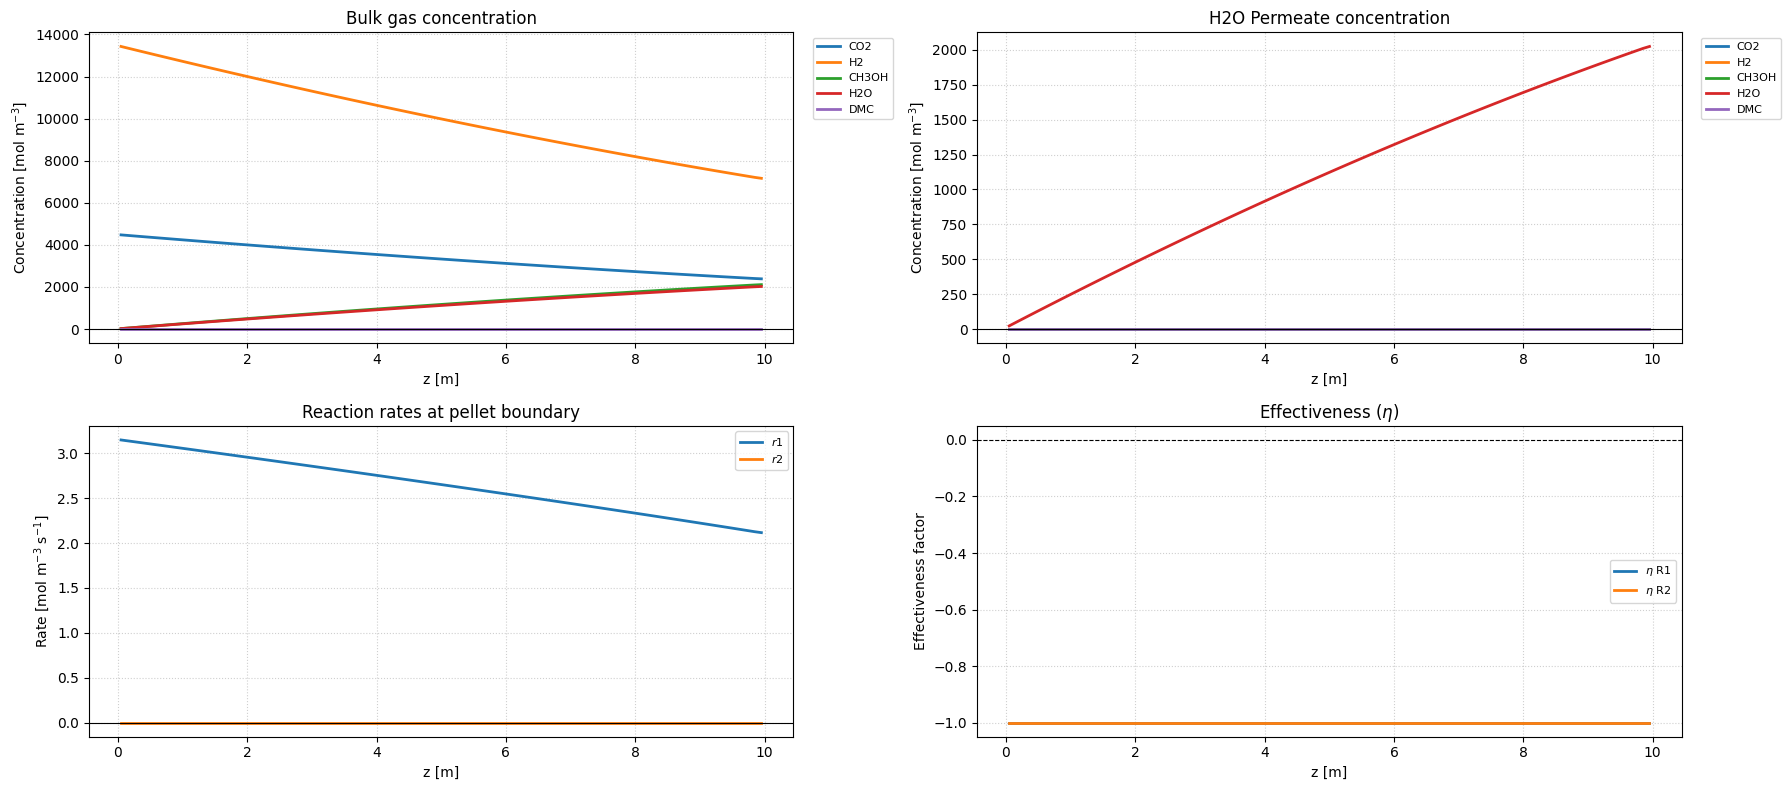

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=False)
axes = axes.flatten()

# axes[0]: Bulk Gas Concentration
for i, label in enumerate(model.species_labels):
    axes[0].plot(model.z_c, c_g[:, i], label=label, linewidth=2)
axes[0].axhline(0.0, color="k", linewidth=0.8)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Concentration [mol m$^{-3}$]")
axes[0].set_title("Bulk gas concentration")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[0].grid(True, linestyle=":", alpha=0.6)

# axes[1]: H2O Permeate Concentration
for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, c_m[:, i], label=label, linewidth=2)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel(r"Concentration [mol m$^{-3}$]")
axes[1].set_title("H2O Permeate concentration")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)

# axes[2]: Reaction Rates
axes[2].plot(model.z_c, r1, label=r"$r1$", linewidth=2)
axes[2].plot(model.z_c, r2, label=r"$r2$", linewidth=2)
axes[2].axhline(0.0, color="k", lw=0.8)
axes[2].set_xlabel("z [m]")
axes[2].set_ylabel("Rate [mol m$^{-3}$ s$^{-1}$]")
axes[2].set_title("Reaction rates at pellet boundary")
axes[2].legend(loc="best", fontsize=8)
axes[2].grid(True, linestyle=":", alpha=0.6)

# axes[3]: Effectiveness Profile 
eta_r1, eta_r2, _, _ = model.effectiveness_profile()
axes[3].plot(model.z_c, eta_r1, label=r"$\eta$ R1", linewidth=2)
axes[3].plot(model.z_c, eta_r2, label=r"$\eta$ R2", linewidth=2)
axes[3].axhline(0.0, color="k", linewidth=0.8, linestyle="--")
axes[3].set_xlabel("z [m]")
axes[3].set_ylabel("Effectiveness factor")
axes[3].set_title(r"Effectiveness ($\eta$)")
axes[3].grid(True, linestyle=":", alpha=0.6)
axes[3].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()